## Customer Segmentation using K-Means

### import libraries

In [71]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
from sklearn.decomposition import PCA
plt.style.use('ggplot')

### Data Understanding

In [72]:
data = pd.read_csv('../data/CC GENERAL.csv')

In [73]:
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [74]:
data.shape

(8950, 18)

In [75]:
data.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='str')

In [76]:
data.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

### drop rows that contain nissing values where CREDIT_LIMIT column include 1 , MINIMUM_PAYMENTS include 313 that represent small percentage of all dataset (8950) rows 

In [77]:
data.dropna(inplace=True )

In [78]:
data.shape

(8636, 18)

In [79]:
data.dtypes

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [80]:
data.duplicated().sum()

np.int64(0)

In [81]:
data.drop(columns=['CUST_ID']  ,inplace=True)

In [82]:
data.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [83]:
data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,0.895035,1025.433874,604.901438,420.843533,994.175523,0.496000,0.205909,0.368820,0.137604,3.313918,15.033233,4522.091030,1784.478099,864.304943,0.159304,11.534391
std,2095.571300,0.207697,2167.107984,1684.307803,917.245182,2121.458303,0.401273,0.300054,0.398093,0.201791,6.912506,25.180468,3659.240379,2909.810090,2372.566350,0.296271,1.310984
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.000000
25%,148.095189,0.909091,43.367500,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.559237,169.163545,0.000000,12.000000
50%,916.855459,1.000000,375.405000,44.995000,94.785000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.675701,312.452292,0.000000,12.000000
75%,2105.195853,1.000000,1145.980000,599.100000,484.147500,1132.385490,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.142090,825.496463,0.166667,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### The monetary features (such as MINIMUM_PAYMENTS, PAYMENTS, PURCHASES, and CREDIT_LIMIT) have much higher scales (ranging up to 76,000 with large standard deviations) compared to count features (PURCHASES_TRX) and frequency features which are bounded between 0 and 1

## Exploratory Data Analysis (EDA)

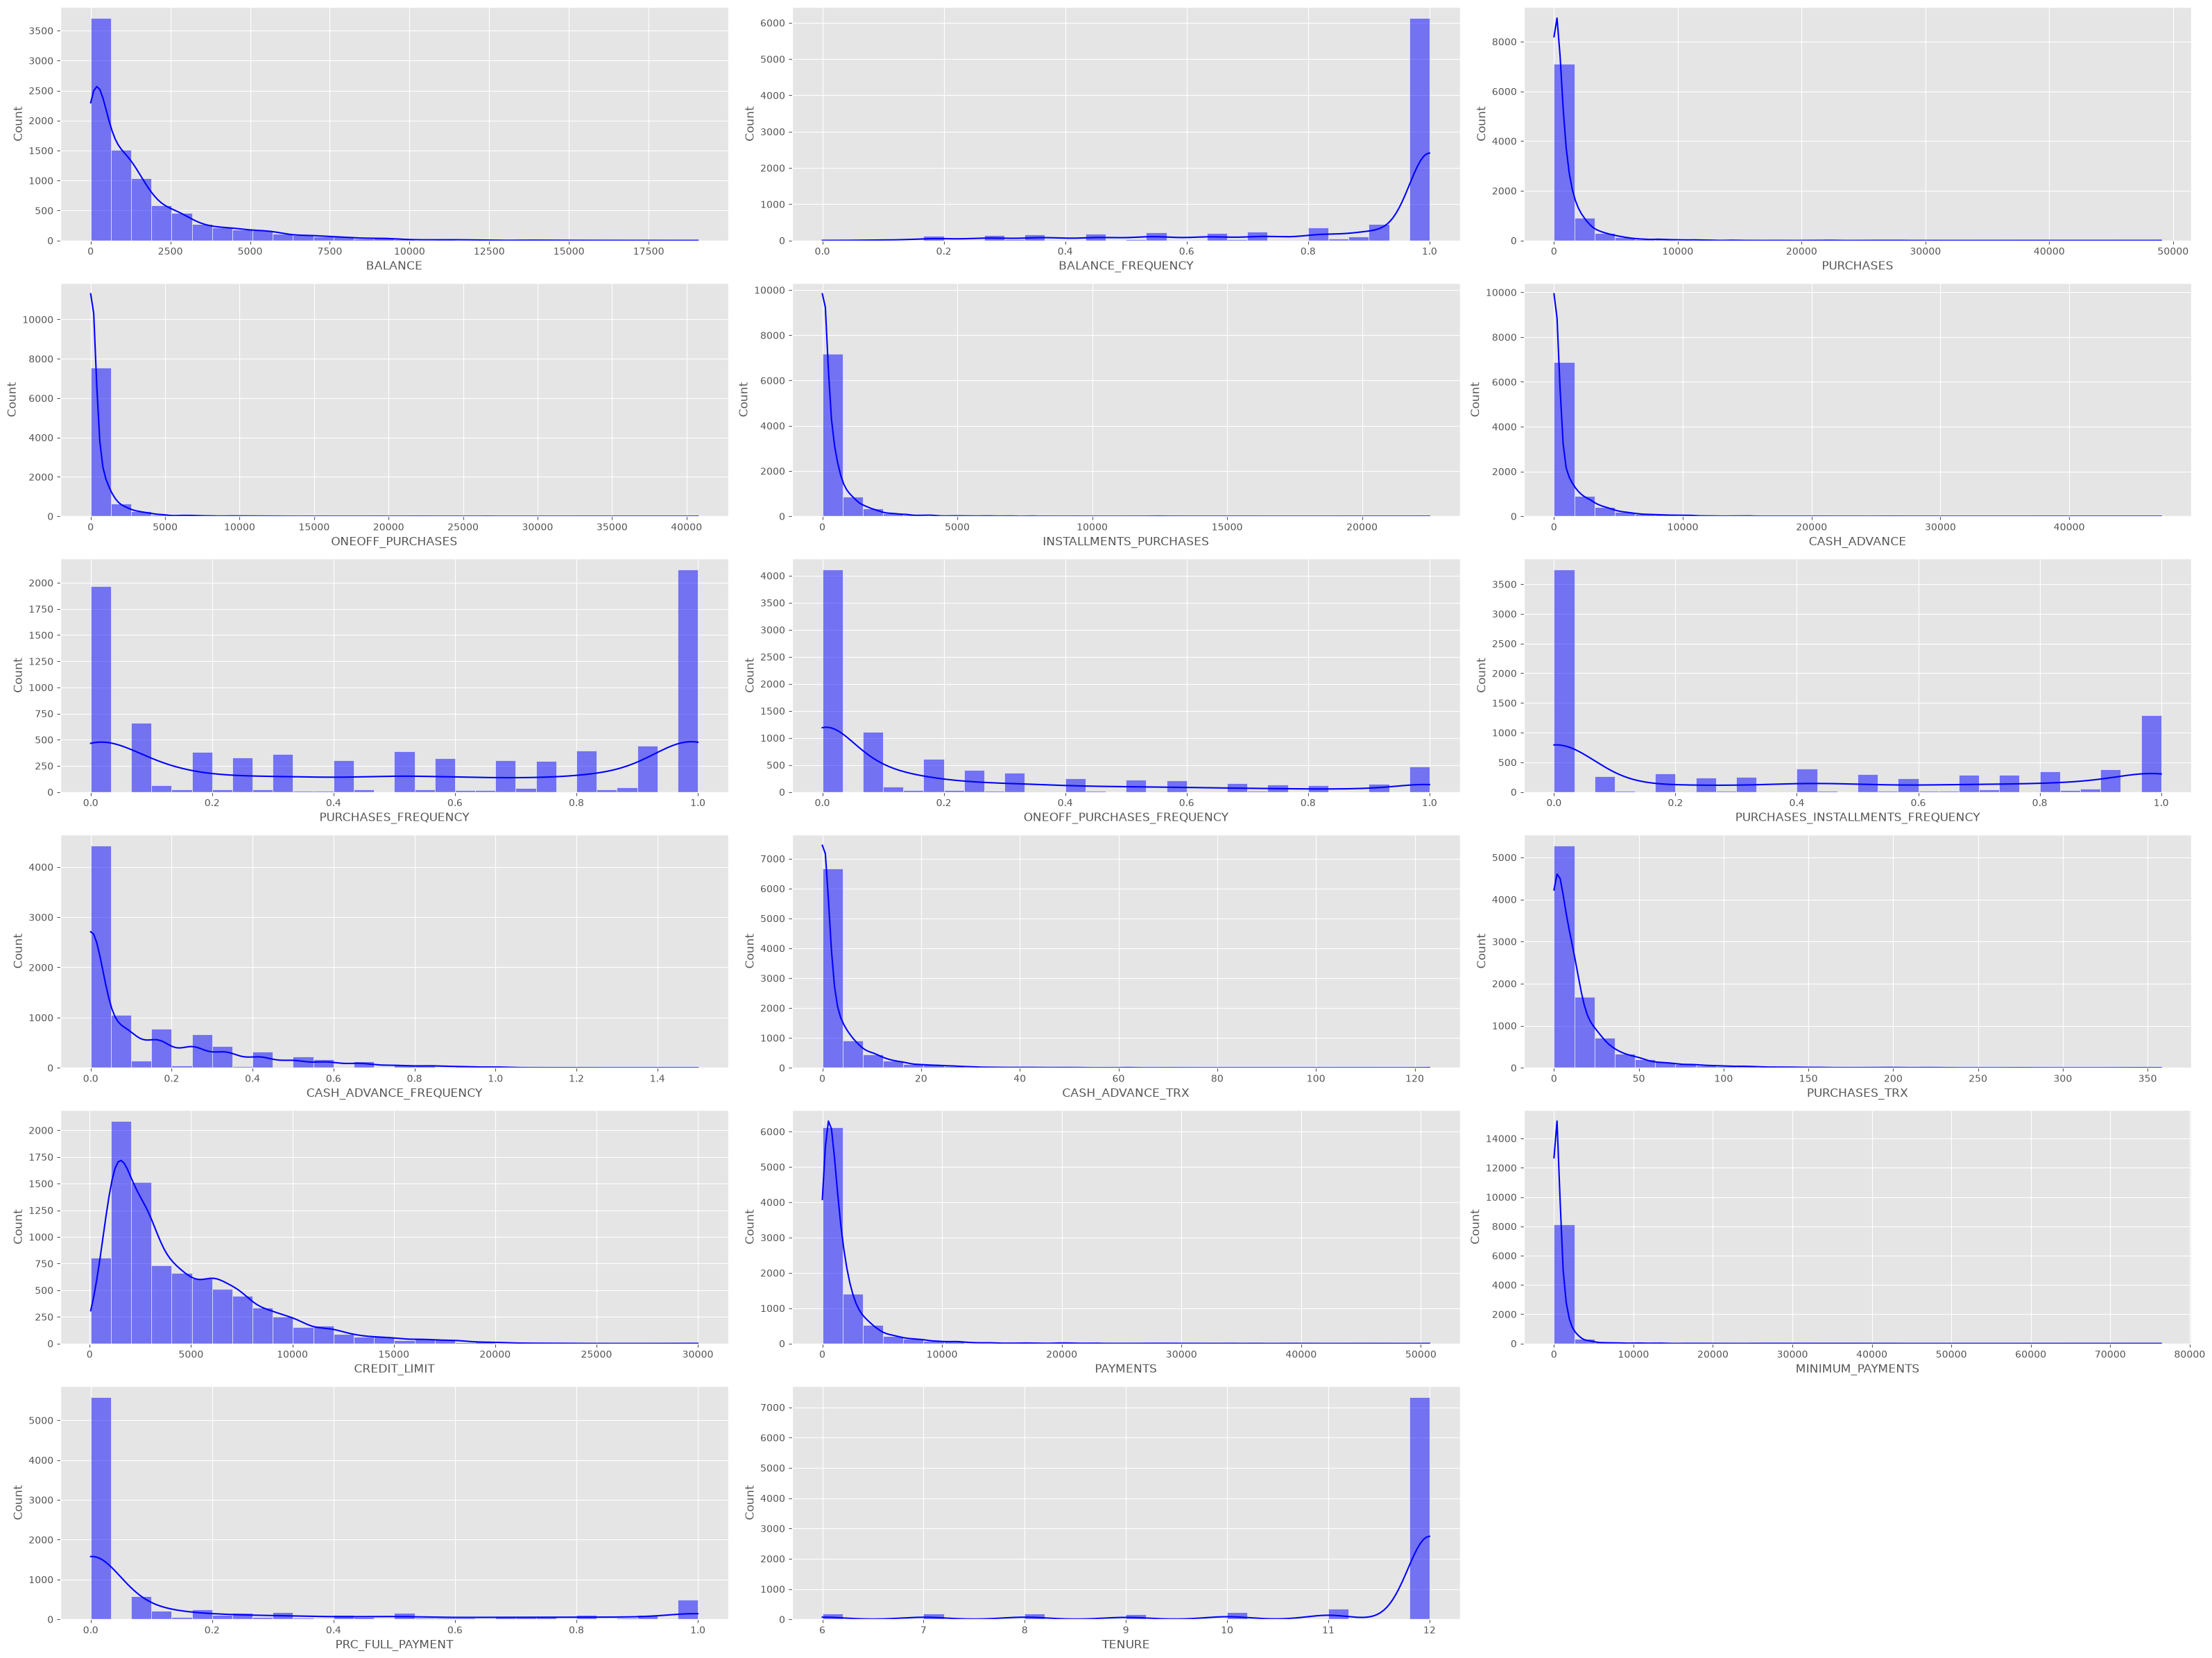

In [84]:
cols = data.columns
plt.figure(figsize=(32,24))
 
for i , col in enumerate(cols ,1 ):
  plt.subplot(6, 3 ,i)
  sns.histplot(data[col] , kde=True ,bins=30 ,color='blue')
  #plt.title(col ,fontsize=10 )

plt.tight_layout()
plt.savefig('../images/Original Feature Distributions.png') 
plt.show()

In [85]:
transformer = FunctionTransformer(np.log1p) 
Data = transformer.transform(data) 
Data

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.597837,4.568506,0.000000,4.568506,0.000000,0.154151,0.000000,0.080042,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,2.564949
1,8.071989,0.646627,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,2.564949
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,2.564949
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.080042,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,2.564949
5,7.501540,0.693147,7.196147,0.000000,7.196147,0.000000,0.510826,0.000000,0.459532,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,2.564949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,1.927413,0.405465,3.086487,3.086487,0.000000,0.000000,0.154151,0.154151,0.000000,0.000000,0.000000,0.693147,6.216606,4.088408,3.794898,0.000000,1.945910
8945,3.384170,0.693147,5.677165,0.000000,5.677165,0.000000,0.693147,0.000000,0.606136,0.000000,0.000000,1.945910,6.908755,5.788719,3.909748,0.405465,1.945910
8947,3.194529,0.606136,4.979489,0.000000,4.979489,0.000000,0.606136,0.000000,0.510826,0.000000,0.000000,1.791759,6.908755,4.410016,4.423869,0.223144,1.945910
8948,2.671218,0.606136,0.000000,0.000000,0.000000,3.625907,0.000000,0.000000,0.000000,0.154151,1.098612,0.000000,6.216606,3.980615,4.038755,0.223144,1.945910


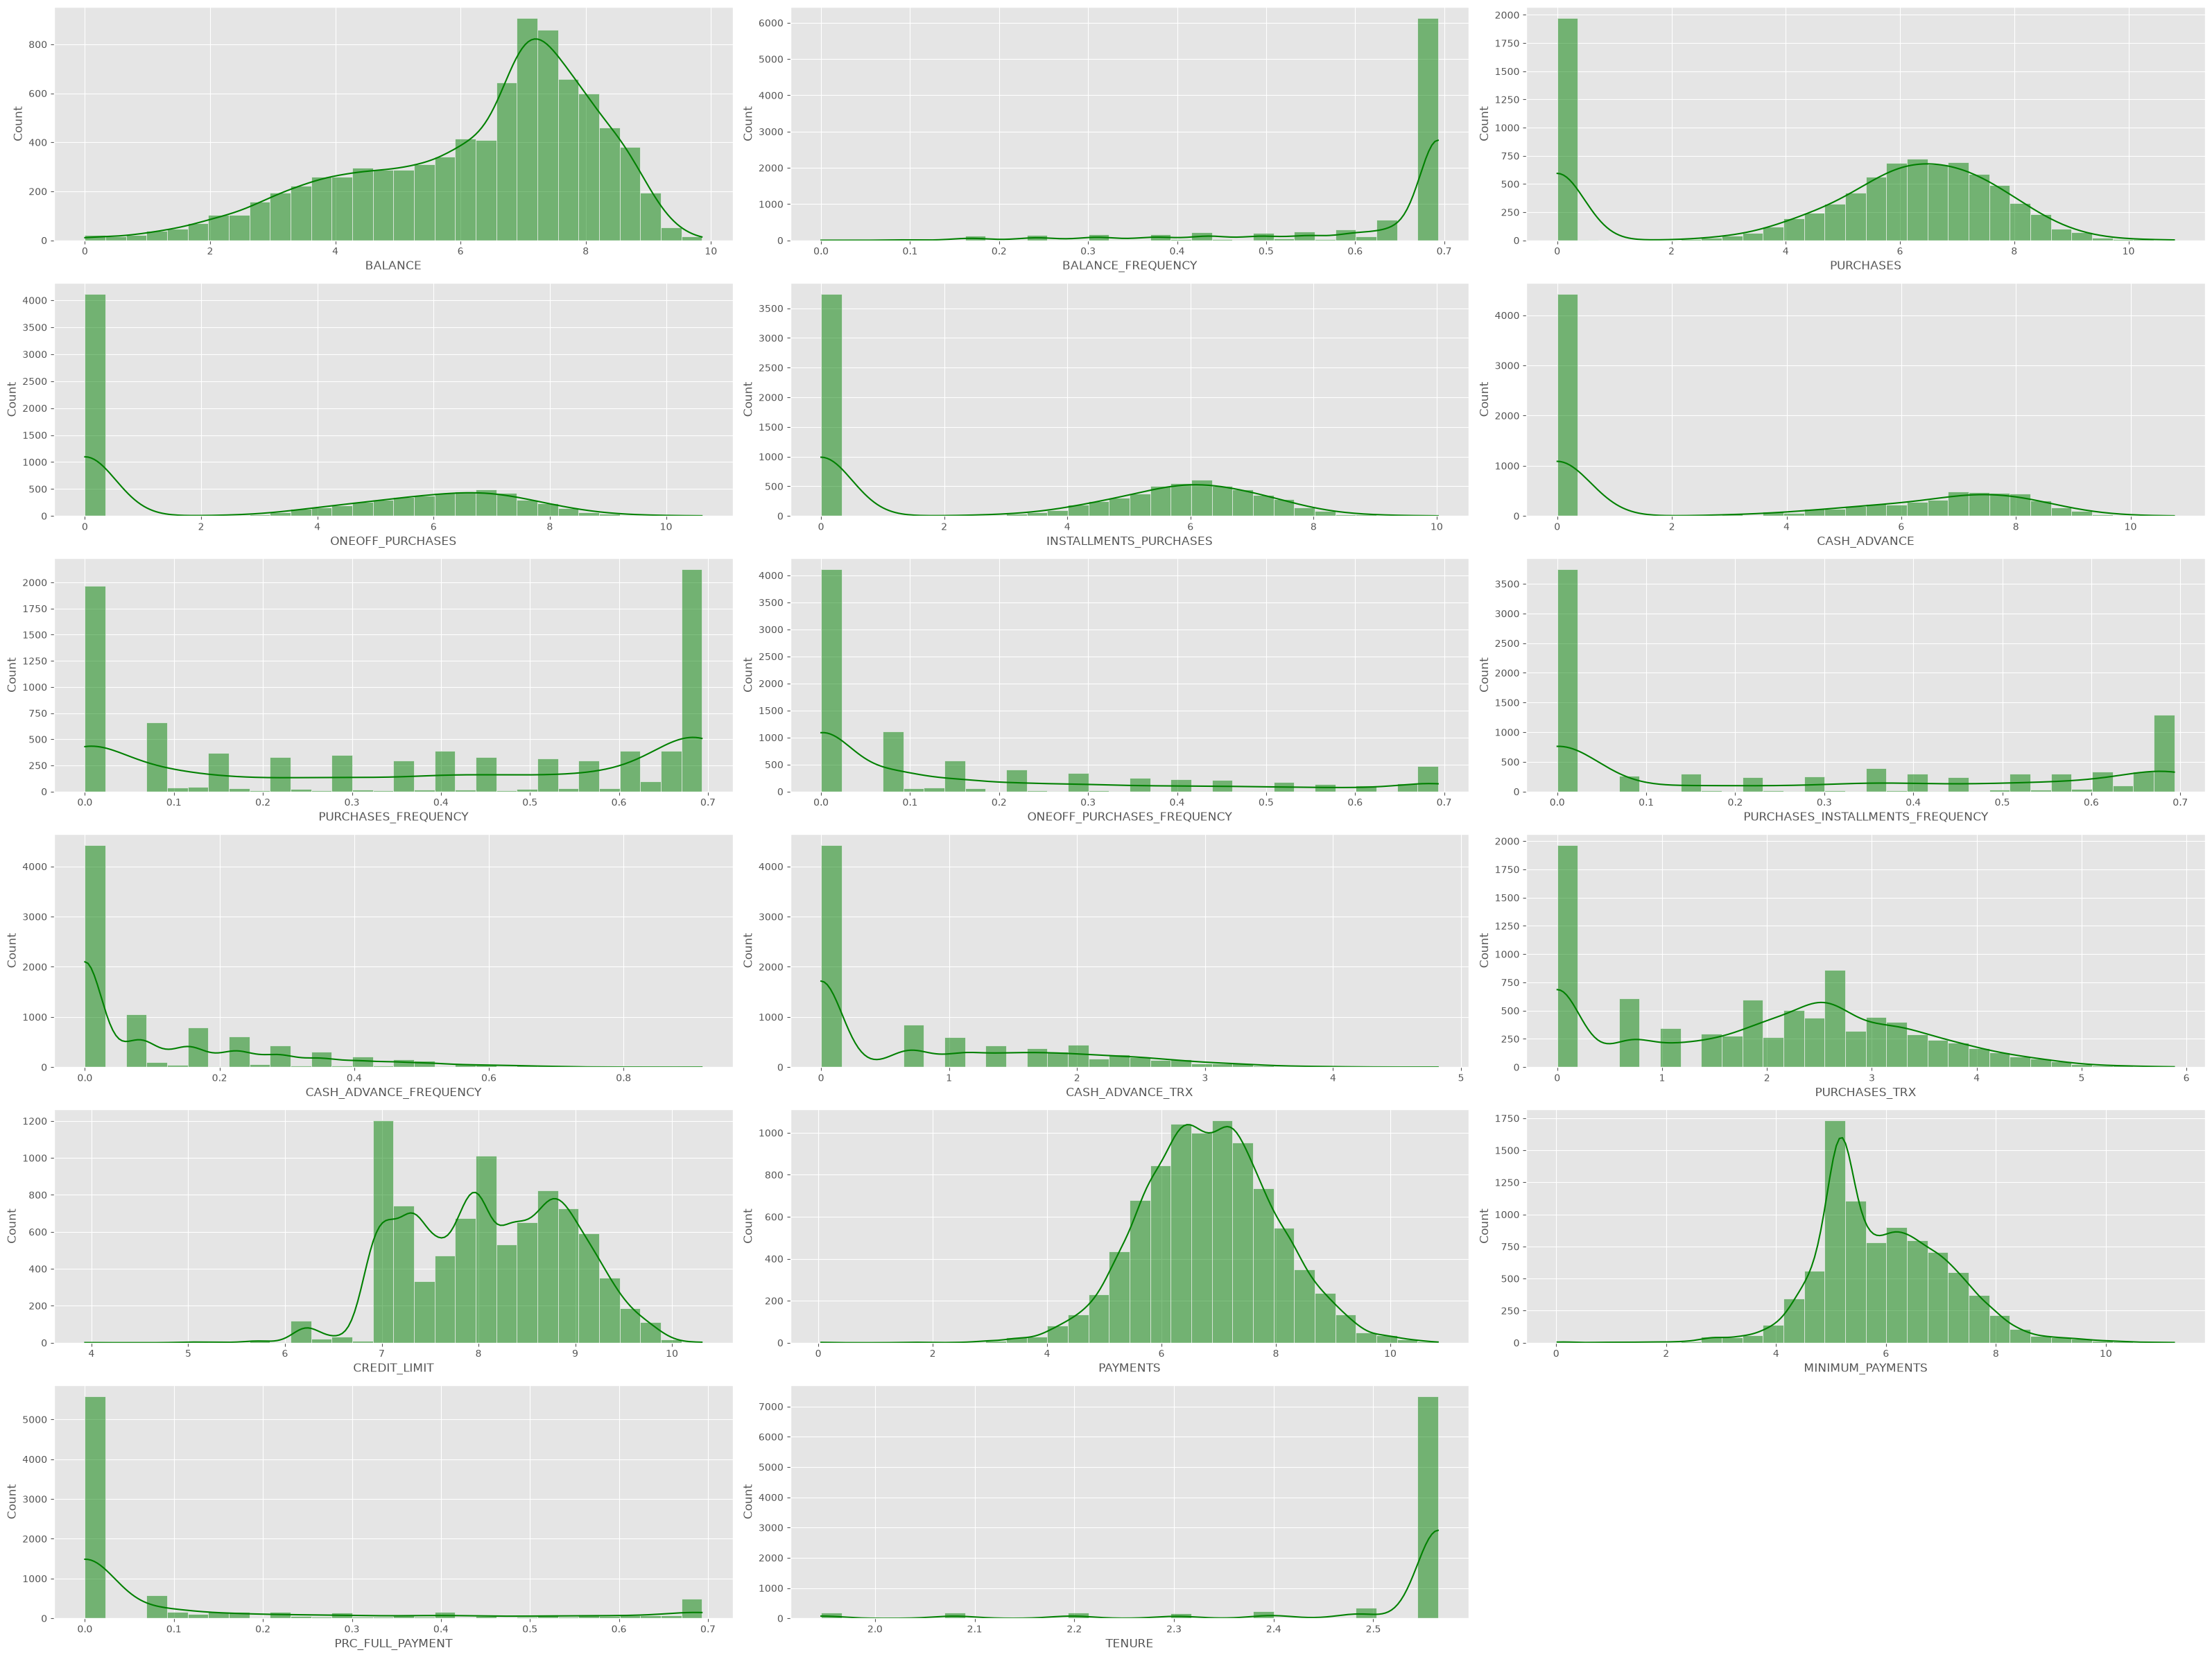

In [86]:
cols = Data.columns
plt.figure(figsize=(32,24))
 
for i , col in enumerate(cols ,1 ):
  plt.subplot(6, 3 ,i)
  sns.histplot(Data[col] , kde=True ,bins=30 ,color= "green")
  #plt.title(col ,fontsize=10 )

plt.tight_layout()
plt.savefig('../images/Log-Transformed Feature Distributions.png')
plt.show()

### Log Transformation Insights
Distribution Normalization: Successfully transformed highly right-skewed financial features ('PAYMENTS', CREDIT_LIMIT, MINIMUM_PAYMENTS) into symmetric, near-Gaussian bell curves.
Scale Compression & Outlier Control: Reduced extreme values from massive ranges ($0$ to $50,000+$) down to a manageable scale ($0$ to $10$), preventing high monetary values from dominating Euclidean distance calculations in K-Means.
Variance Unlocking: De-compressed the heavy accumulation of data near zero, revealing subtle behavioral differences among lower-to-mid spending customers that were previously hidden.

In [87]:
scaler = StandardScaler()
scaledData = scaler.fit_transform(Data) 
scaledData = pd.DataFrame(scaledData , index=Data.index , columns=Data.columns) 

In [88]:
scaledData

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.334707,-0.270722,-0.123312,-0.996024,0.381976,-0.937894,-0.761203,-0.740409,-0.684522,-0.731226,-0.817000,-0.593218,-1.448165,-1.295478,-0.821250,-0.569607,0.341778
1,0.952729,0.115912,-1.686451,-0.996024,-1.096108,1.518315,-1.317269,-0.740409,-0.968116,0.681686,0.768516,-1.390107,0.917235,1.297354,0.887368,0.367222,0.341778
2,0.821135,0.484556,0.589495,1.049151,-1.096108,-0.937894,1.183110,2.440893,-0.968116,-0.731226,-0.817000,0.470403,1.001126,-0.327811,0.437336,-0.569607,0.341778
4,0.233137,0.484556,-0.717052,-0.124918,-1.096108,-0.937894,-1.028534,-0.373042,-0.968116,-0.731226,-0.817000,-0.887326,-1.226644,-0.253271,-0.351329,-0.569607,0.341778
5,0.651839,0.484556,0.775749,-0.996024,1.232117,-0.937894,0.525425,-0.740409,0.660027,-0.731226,-0.817000,0.203671,-0.733891,0.370793,1.566464,-0.569607,0.341778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,-2.288300,-1.795159,-0.630393,-0.047046,-1.096108,-0.937894,-0.761203,-0.032910,-0.968116,-0.731226,-0.817000,-0.887326,-2.289894,-2.350564,-1.787956,-0.569607,-4.512398
8945,-1.519916,0.484556,0.256021,-0.996024,0.740669,-0.937894,1.183110,-0.740409,1.179449,-0.731226,-0.817000,0.021377,-1.448165,-0.884686,-1.691444,1.323304,-4.512398
8947,-1.619945,-0.204961,0.017308,-0.996024,0.514944,-0.937894,0.869235,-0.740409,0.841762,-0.731226,-0.817000,-0.090437,-1.448165,-2.073298,-1.259409,0.472137,-4.512398
8948,-1.895971,-0.204961,-1.686451,-0.996024,-1.096108,0.077508,-1.317269,-0.740409,-0.968116,0.244835,0.265283,-1.390107,-2.289894,-2.443495,-1.583035,0.472137,-4.512398


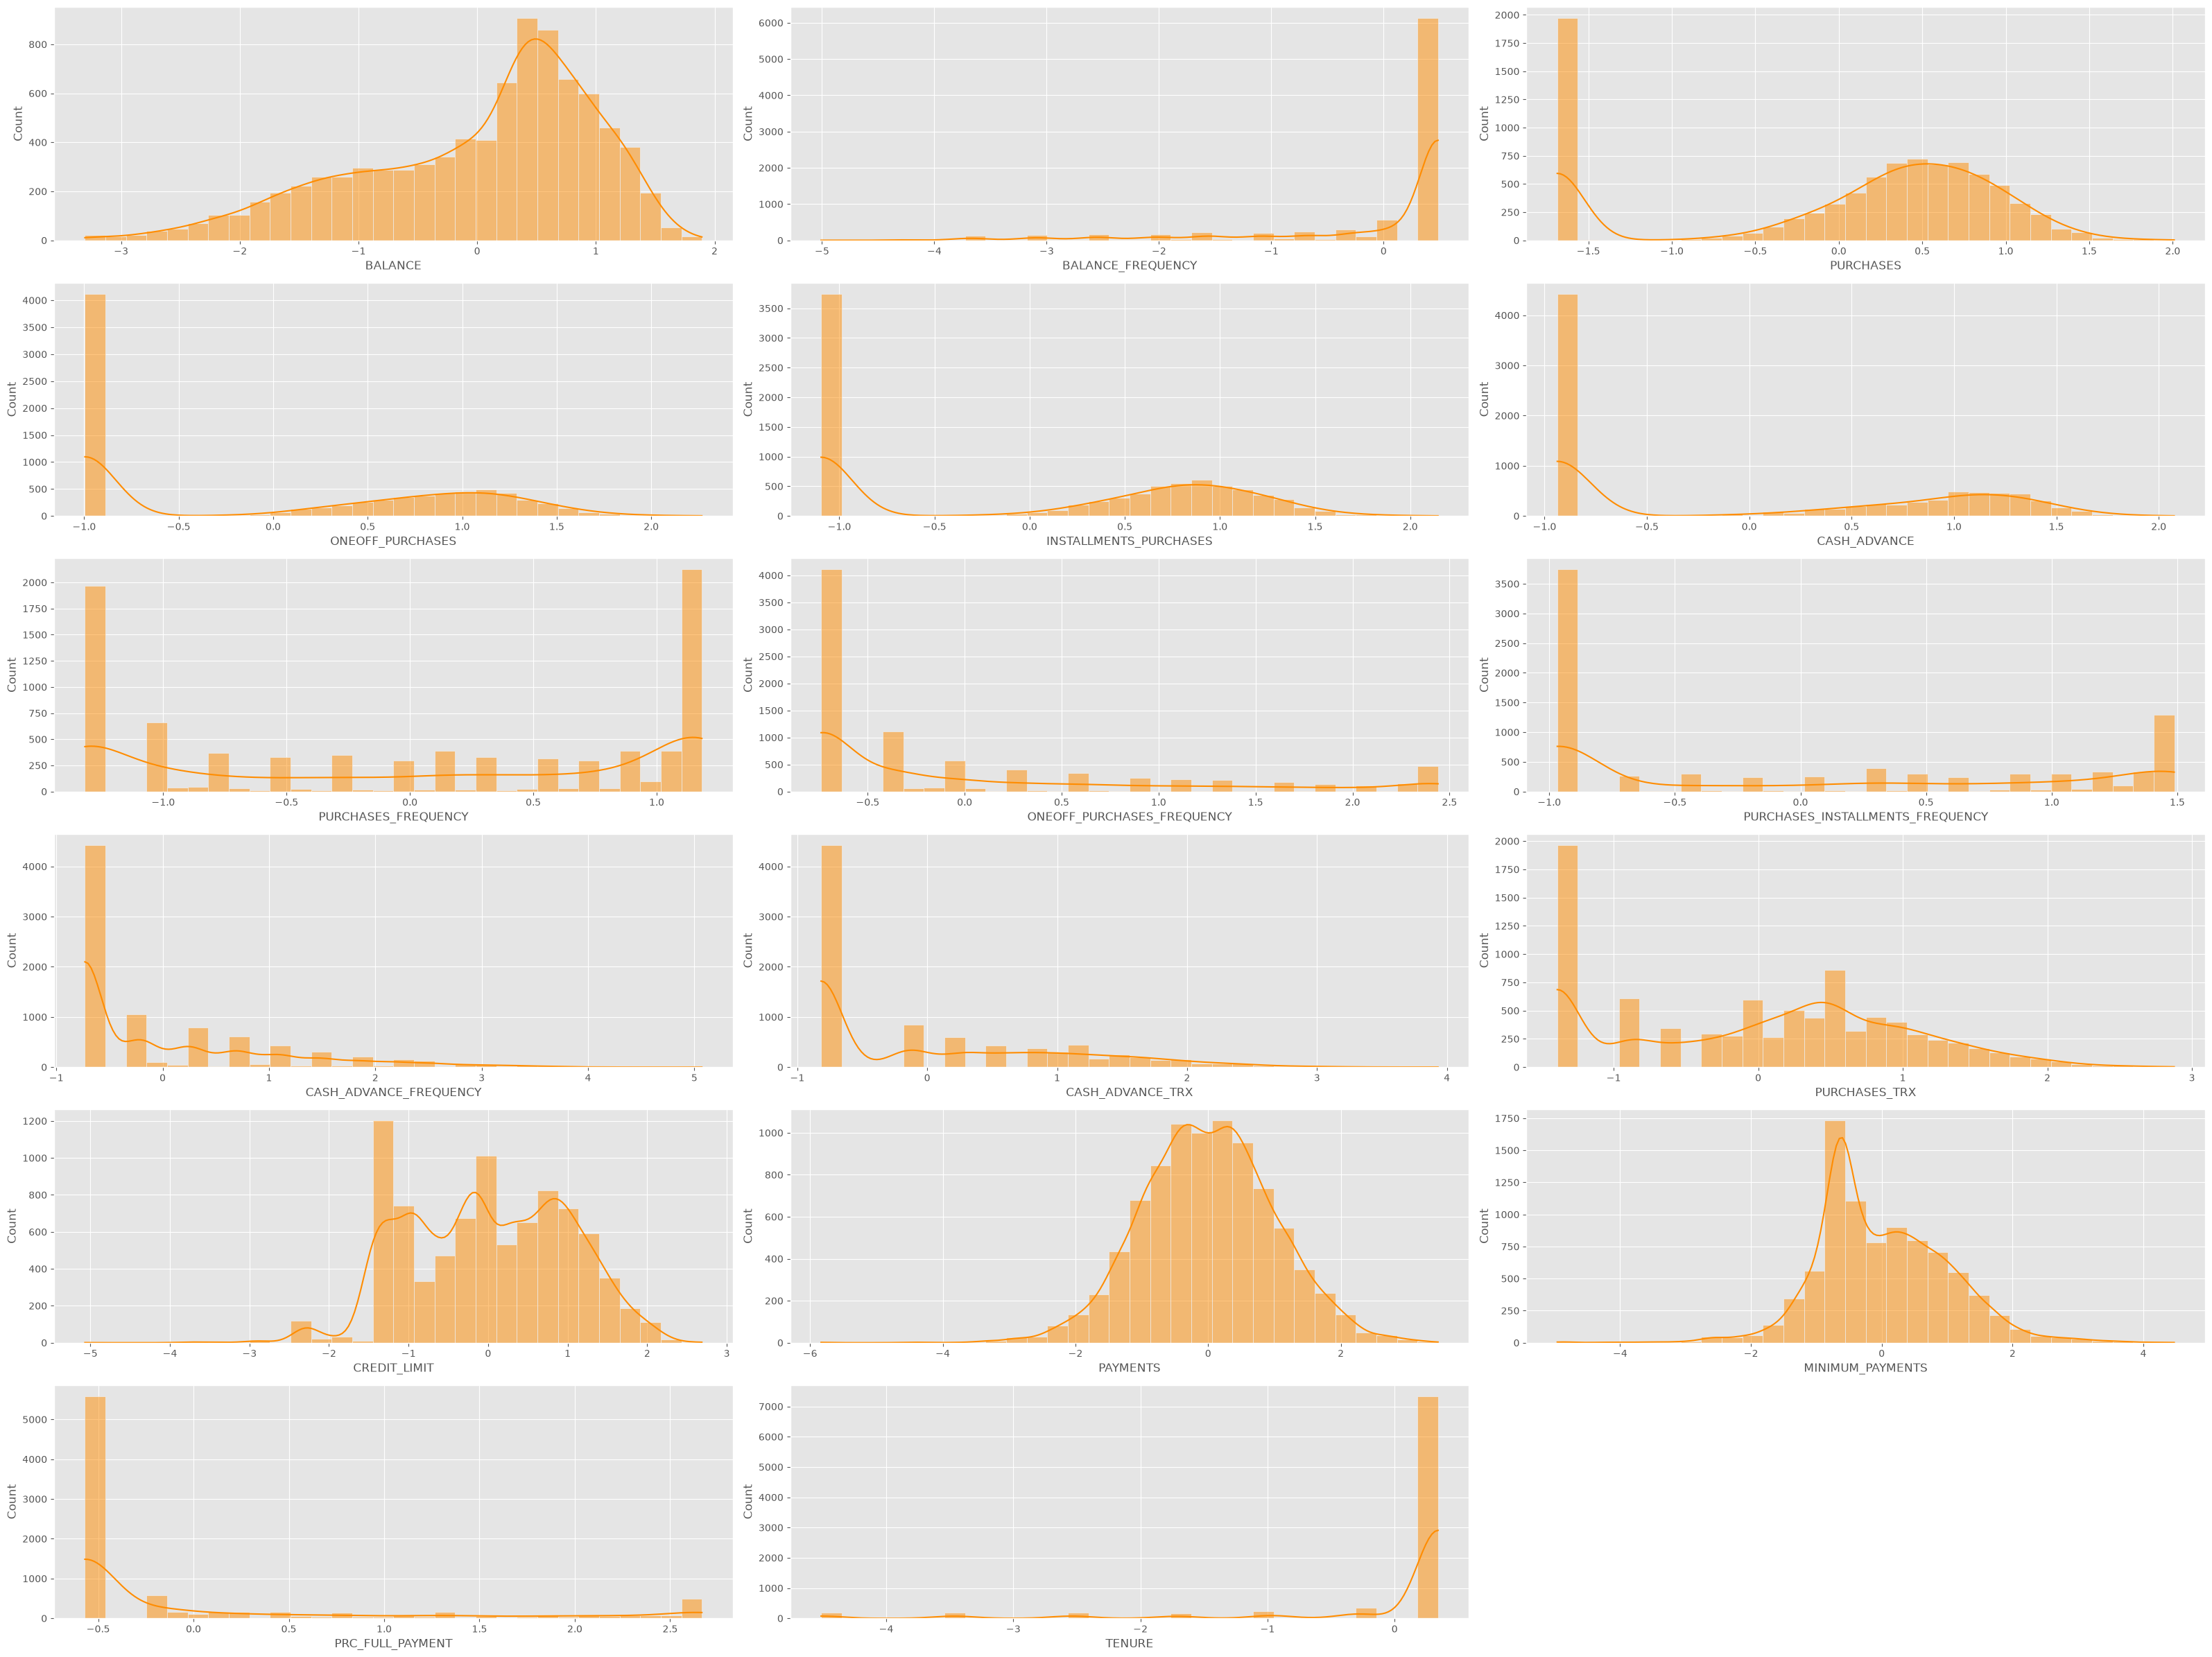

In [89]:
cols = scaledData.columns
plt.figure(figsize=(32,24))
 
for i , col in enumerate(cols ,1 ):
  plt.subplot(6, 3 ,i)
  sns.histplot(scaledData[col] , kde=True ,bins=30 ,color="darkorange")
  #plt.title(col ,fontsize=10 )

plt.tight_layout()
plt.savefig('../images/Standardized Feature Distributions.png')
plt.show()

### Z-Score Normalization: Standardized all features to a mean of $0$ and a standard deviation of $1$, mapping most values smoothly into a uniform operational range (typically between $-3$ and $+3$).Equal Distance Weighting: Eliminated unit and magnitude disparities across variables, guaranteeing that every feature contributes equally to Euclidean distance calculations in K-Means.Distribution Shape Preservation: Successfully retained the normalized, post-transformation shapes achieved in earlier preprocessing steps while unifying their underlying variance

## Choosing the Number of Clusters

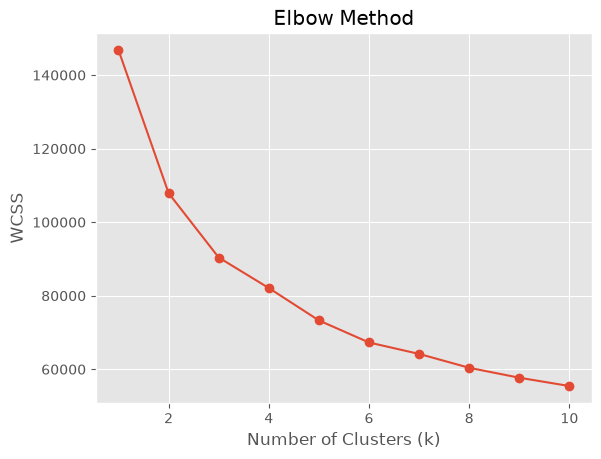

In [90]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k , random_state=42)
    kmeans.fit(scaledData) 
    wcss.append(kmeans.inertia_) 

# plotting WCSS values 
plt.plot(range(1,11) , wcss , marker='o')
plt.title('Elbow Method') 
plt.xlabel('Number of Clusters (k)') 
plt.ylabel('WCSS')
plt.savefig('../images/Elbow Method.png')
plt.show()

### Elbow Point Identification: The WCSS curve exhibits a distinct inflection ("elbow") between  K = 5, marking the transition from a rapid drop to a gradual decrease.Optimal Complexity Balance: Choosing K = 5 achieves an optimal tradeoff between minimizing intra-cluster variance (WCSS) and avoiding over-segmentation.

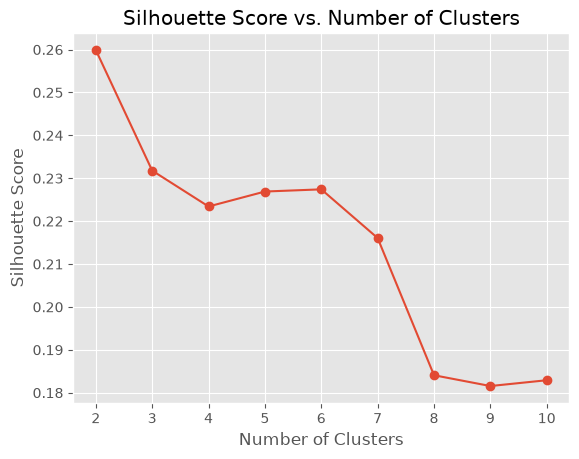

In [91]:
# Silhouette Score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k , random_state=42) 
    labels = kmeans.fit_predict(scaledData)
    scores.append(silhouette_score(scaledData , labels))

plt.plot(range(2, 11), scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.savefig('../images/Silhouette Score.png')
plt.show()

### Peak Separation (K=2): K=2 achieves the highest overall Silhouette Score ($\approx 0.26$), representing a broad, macro-level split of the customer base.Local Peak at K=5: A clear local peak around K=5($\approx 0.227$) validates the Elbow Method, offering a better balance between mathematical separation and granular business segmentation.

### Do Both Methods Agree? Yes. While K = 2 is the global maximum for Silhouette score, both methods independently highlight K = 5—it marks the primary elbow inflection point and creates a clear local peak in the Silhouette profile.

### Selected K for Final Model: K = 5.Justification: K = 5 strikes the best balance between mathematical validity and practical business utility. A 2-cluster split is too broad to build actionable customer personas for credit card strategy, whereas K = 5 captures distinct, granular behavioral segments while maintaining solid cluster separation before scores drop significantly at K \ge 7.

## K-Means Clustering

In [92]:
customerSegmentationModel = KMeans(n_clusters=5, random_state=42) 


In [93]:
customerSegmentationModel.fit_predict(scaledData) 

array([4, 0, 2, ..., 1, 4, 4], shape=(8636,), dtype=int32)

In [94]:
data['cluster'] = customerSegmentationModel.labels_

In [95]:
centroids = customerSegmentationModel.cluster_centers_

In [96]:
final_score = silhouette_score(scaledData , data['cluster'])
print(f"Final Silhouette Score: {final_score:.4f}")

Final Silhouette Score: 0.2269


In [97]:
raw_centroids = scaler.inverse_transform(centroids)

In [98]:
original_scale_centroids = np.expm1(raw_centroids)

In [99]:
# How many customers belong to each cluster
data['cluster'].value_counts()

cluster
0    2284
2    1866
1    1811
3    1396
4    1279
Name: count, dtype: int64

In [100]:
# How many iterations were required
customerSegmentationModel.n_iter_

34

In [101]:
# What are the final cluster centroids
print(original_scale_centroids)

[[1.52009542e+03 9.30370964e-01 1.27797239e+00 1.02394605e+00
  1.31185027e-01 9.24844900e+02 2.07342978e-02 1.62879380e-02
  3.78785955e-03 2.67421152e-01 4.42655243e+00 1.87558738e-01
  3.03308798e+03 8.83509042e+02 5.77929094e+02 2.77330117e-02
  1.13045891e+01]
 [1.36739108e+02 9.08357863e-01 4.19945268e+02 1.37917640e+00
  3.92619544e+02 5.81205966e-01 7.82518319e-01 2.23654043e-02
  7.35740051e-01 9.34720783e-03 8.29615705e-02 1.14717919e+01
  2.20540175e+03 5.04377607e+02 2.28084704e+02 2.68832494e-01
  1.13605316e+01]
 [7.32483913e+02 9.72645213e-01 1.81749920e+03 1.04005615e+03
  1.59912096e+02 7.48987630e-01 8.22259034e-01 5.65417182e-01
  4.90233038e-01 9.90428987e-03 9.13289697e-02 2.61694592e+01
  4.96363044e+03 1.74184657e+03 3.72495631e+02 2.05247300e-01
  1.18487850e+01]
 [2.37369178e+03 9.73773309e-01 8.33812849e+02 1.56137274e+02
  1.03032849e+02 1.55299079e+03 6.45711948e-01 2.74797984e-01
  4.36009313e-01 3.28589379e-01 6.35510995e+00 1.41272436e+01
  4.51809475e+03

In [102]:
covariance_matrix = scaledData.cov() 

In [103]:
print("Covariance Matrix :")
print(covariance_matrix) 

Covariance Matrix :
                                   BALANCE  BALANCE_FREQUENCY  PURCHASES  \
BALANCE                           1.000116           0.594906  -0.098760   
BALANCE_FREQUENCY                 0.594906           1.000116   0.078183   
PURCHASES                        -0.098760           0.078183   1.000116   
ONEOFF_PURCHASES                  0.162773           0.115971   0.684673   
INSTALLMENTS_PURCHASES           -0.127347           0.107773   0.689002   
CASH_ADVANCE                      0.533414           0.159455  -0.497118   
PURCHASES_FREQUENCY              -0.132972           0.211471   0.818360   
ONEOFF_PURCHASES_FREQUENCY        0.135754           0.183259   0.576495   
PURCHASES_INSTALLMENTS_FREQUENCY -0.131677           0.172832   0.612666   
CASH_ADVANCE_FREQUENCY            0.476797           0.185641  -0.382163   
CASH_ADVANCE_TRX                  0.511143           0.182954  -0.420808   
PURCHASES_TRX                    -0.041781           0.187150   0.89

In [104]:
#  Principal Component Analysis (PCA) for dimensionality-reduction
pca = PCA(n_components=2)
data_pca = pca.fit_transform(scaledData) 

In [105]:
pca_df = pd.DataFrame(data_pca ,columns=['PC1', 'PC2']) 
pca_df['Cluster'] = customerSegmentationModel.labels_

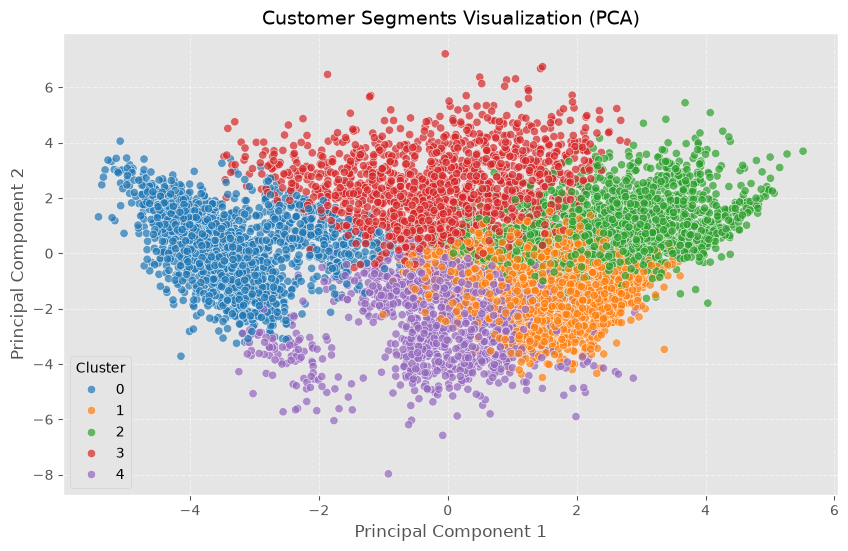

In [106]:
plt.figure(figsize=(10,6)) 
sns.scatterplot(x='PC1' , y='PC2' ,hue='Cluster' , data=pca_df ,palette='tab10',alpha=0.7) 
plt.title('Customer Segments Visualization (PCA)' , fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12) 
plt.legend(title='Cluster') 
plt.grid(True , linestyle='--' , alpha=0.5) 
plt.savefig('../images/Customer Segments Visualization (PCA).png')
plt.show() 

### Clear Density Cores: Cluster 0 forms a well-isolated segment on the far left, while Clusters 1, 3, and 4 create a continuous spectrum in the center with blending boundaries.Metric Consistency: The visual overlap directly reflects the moderate Silhouette Score ($\approx 0.227$), confirming that customer financial behaviors transition smoothly rather than dividing into rigid, isolated categories.Dimensionality Compression Effect: Reducing 17 features to 2 Principal Components compresses some spatial separation, yet 5 distinct cluster centers remain clearly visible for business segmentation.

## Customer Segment Analysis

In [107]:
cluster_summary= data.groupby('cluster').agg(
      Avg_Cash_Advace = ('CASH_ADVANCE', 'mean')  ,
      Avg_Payments=('PAYMENTS', 'mean'),
     Avg_Purchases=('PURCHASES', 'mean'),
     Avg_Balance=('BALANCE', 'mean'),
     Customers = ('BALANCE', 'count')

).reset_index()

In [108]:
cluster_summary

,cluster,Avg_Cash_Advace,Avg_Payments,Avg_Purchases,Avg_Balance,Customers
0,0,2006.844278,1676.180366,26.220455,2281.420494,2284
1,1,38.952459,753.813832,612.452656,434.443798,1811
2,2,47.314686,2715.315933,2837.495059,1506.075033,1866
3,3,2671.364771,2916.819157,1375.087213,3334.943821,1396
4,4,89.140077,843.268948,369.210422,285.159078,1279


### 1. Cluster Characteristics & Business Names

Cluster 0: Cash-Dependent Borrowers:
High reliance on cash advances with almost zero retail purchases and high maintained balances.

Cluster 1: Moderate Everyday Shoppers:
Low balance, minimal cash advance usage, and moderate purchase activity.

Cluster 2: Big Spenders / Premium Shoppers:
Highest purchase volume, strong payment rates, and virtually no cash advances.

Cluster 3: High-Value Power Users:
Highest total financial throughput across balances, payments, cash advances, and high purchases.

Cluster 4: Low-Engagement / Budget Users:
Lowest balances and low overall transaction activity across all categories.

2. Highest-Spending Customers:
Cluster 2

3. Highest Cash-Advance Usage:
Cluster 3

4. Most Active Customers:
Cluster 3 (Overall Financial Activity)